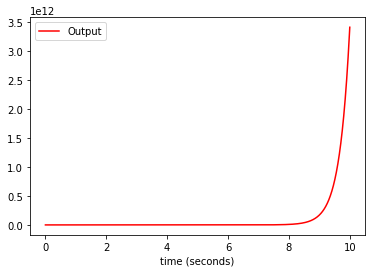

In [1]:
import sys
sys.path.append("../")

from lib.data.dataplot import *
from lib.utils.time import *

class S:
    
    def __init__(self, a, b):
        self.y = 0
        self.a = a
        self.b = b
        
    def evaluate(self, delta_t, _input):
        y = self.y - self.a * delta_t * self.y + self.b * delta_t * _input
        self.y = y
        return y
    
class CompoundSystem:
    
    def __init__(self):
        self.s1 = S(0.5, 1)
        self.s2 = S(-3, 1)
        self.s3 = S(1, 4)
        
    def evaluate(self, delta_t, _input):
        out_s1 = self.s1.evaluate(delta_t, _input)
        out_s2 = self.s2.evaluate(delta_t, _input)
        out_s3 = self.s3.evaluate(delta_t, out_s1)
        return out_s2 + out_s3

dp = DataPlotter()
dp.set_x("time (seconds)")
dp.add_y("out", "Output")

s = CompoundSystem()
u = 1

t = Time(use_fake_time=True)
t.start()
while t.get() < 10:

    t.sleep(0.001)
    delta_t = t.elapsed()
    
    y = s.evaluate(delta_t, u)
    
    dp.append_x(t.get())
    dp.append_y("out", y)

dp.plot()